In [18]:
import pandas as pd

# Load the CSV files into dataframes
df_data = pd.read_csv('/tmp/needle/data.csv')
df_detailed_labels = pd.read_csv('/tmp/needle/detailed_labels.csv')
df_labels = pd.read_csv('/tmp/needle/labels.csv')
df_weights = pd.read_csv('/tmp/needle/weights.csv')

# Merge them together using multiindex (concat with keys for hierarchical index)
merged_df = pd.concat([df_data, df_detailed_labels, df_labels, df_weights], keys=['data', 'detailed_labels', 'labels', 'weights'], ignore_index=True)

In [19]:
merged_df

,Unnamed: 0,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_had_pt,PRI_had_eta,PRI_had_phi,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,...,DER_prodeta_jet_jet,DER_deltar_had_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_had,DER_met_phi_centrality,DER_lep_eta_centrality,detailed_labels,labels,weights
0,0,43.058,-1.867,-0.975,34.504,-2.018,2.560,-25.000,-25.000,-25.000,...,-25.000000,2.752330,22.494236,77.562000,1.247913,1.153226,-2.500000e+01,NaN,NaN,NaN
1,1,33.866,-1.297,-1.794,35.239,-2.205,1.366,-25.000,-25.000,-25.000,...,-25.000000,3.252499,6.049912,69.104996,0.961038,-1.413810,-2.500000e+01,NaN,NaN,NaN
2,2,22.503,1.599,0.465,28.521,0.041,-2.322,-25.000,-25.000,-25.000,...,-25.000000,3.192919,16.337086,51.024002,0.788998,0.898266,-2.500000e+01,NaN,NaN,NaN
3,3,32.731,-1.311,-0.094,38.888,-1.341,-3.119,95.853,-1.977,0.318,...,4.347423,3.025148,6.111954,268.702000,0.841673,1.413865,5.242726e-22,NaN,NaN,NaN
4,4,20.886,-1.845,0.745,29.035,-1.464,-1.818,27.936,-1.529,2.727,...,-25.000000,2.591163,14.539318,77.856995,0.719339,-0.191717,-2.500000e+01,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3365359,939662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3365360,939663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3365361,939664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3365362,939665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


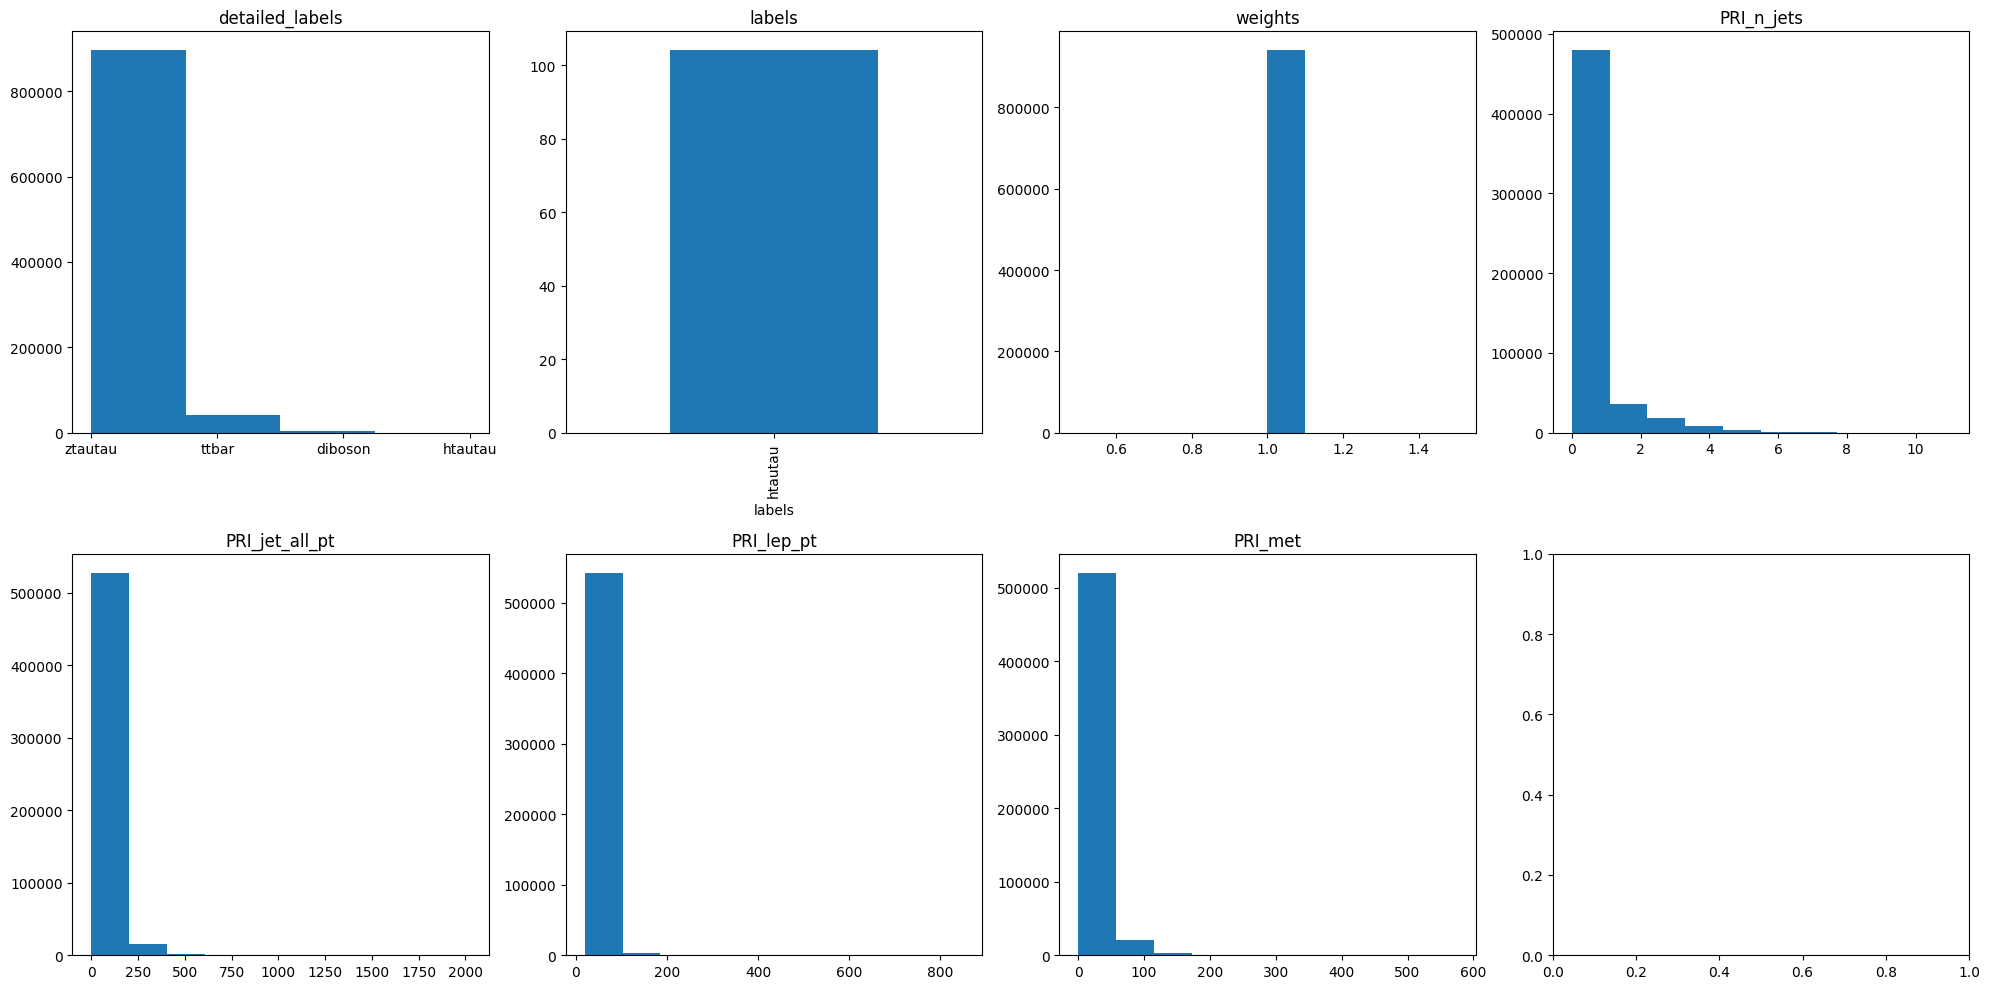

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Histogram for detailed_labels
axes[0, 0].hist(df_detailed_labels['detailed_labels'].dropna(), bins=len(df_detailed_labels['detailed_labels'].unique()))
axes[0, 0].set_title('detailed_labels')

# Bar plot for labels (value counts)
df_labels['labels'].value_counts().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('labels')

# Histogram for weights
axes[0, 2].hist(df_weights['weights'])
axes[0, 2].set_title('weights')

# Histogram for PRI_n_jets
axes[0, 3].hist(df_data['PRI_n_jets'])
axes[0, 3].set_title('PRI_n_jets')

# Histogram for PRI_jet_all_pt
axes[1, 0].hist(df_data['PRI_jet_all_pt'])
axes[1, 0].set_title('PRI_jet_all_pt')

# Histogram for PRI_lep_pt
axes[1, 1].hist(df_data['PRI_lep_pt'])
axes[1, 1].set_title('PRI_lep_pt')

# Histogram for PRI_met
axes[1, 2].hist(df_data['PRI_met'])
axes[1, 2].set_title('PRI_met')

plt.tight_layout()
plt.show()

In [21]:
import sys

sys.path.append("..")

from utils.stats import (
    compute_mu_nuan_2NP_class,
    fit_2D_splines_bin_by_bin_from_dict,
    string_to_tuple_str,
)
import torch

In [22]:
data_1j = torch.load("/tmp/needle/data_1j").cpu().numpy()
data_2j = torch.load("/tmp/needle/data_2j").cpu().numpy()

In [24]:
data_1j[0]

array([ 3.2711647e+00,  3.7000000e-02,  2.0160000e+00,  3.8632109e+00,
       -4.7499999e-01, -5.6000000e-01,  3.6757941e+00, -4.0700001e-01,
       -2.4990001e+00,  3.6757941e+00,  2.2586331e+00,  1.3080000e+00,
        1.1007905e+01,  4.2548628e+00,  3.4787674e+00,  2.6263893e+00,
        2.7687104e+00,  4.7312741e+00,  5.5319417e-01,  1.3892606e+00,
        5.0413812e-05,  4.2380232e-04,  9.4498508e-04,  3.3261720e-03],
      dtype=float32)

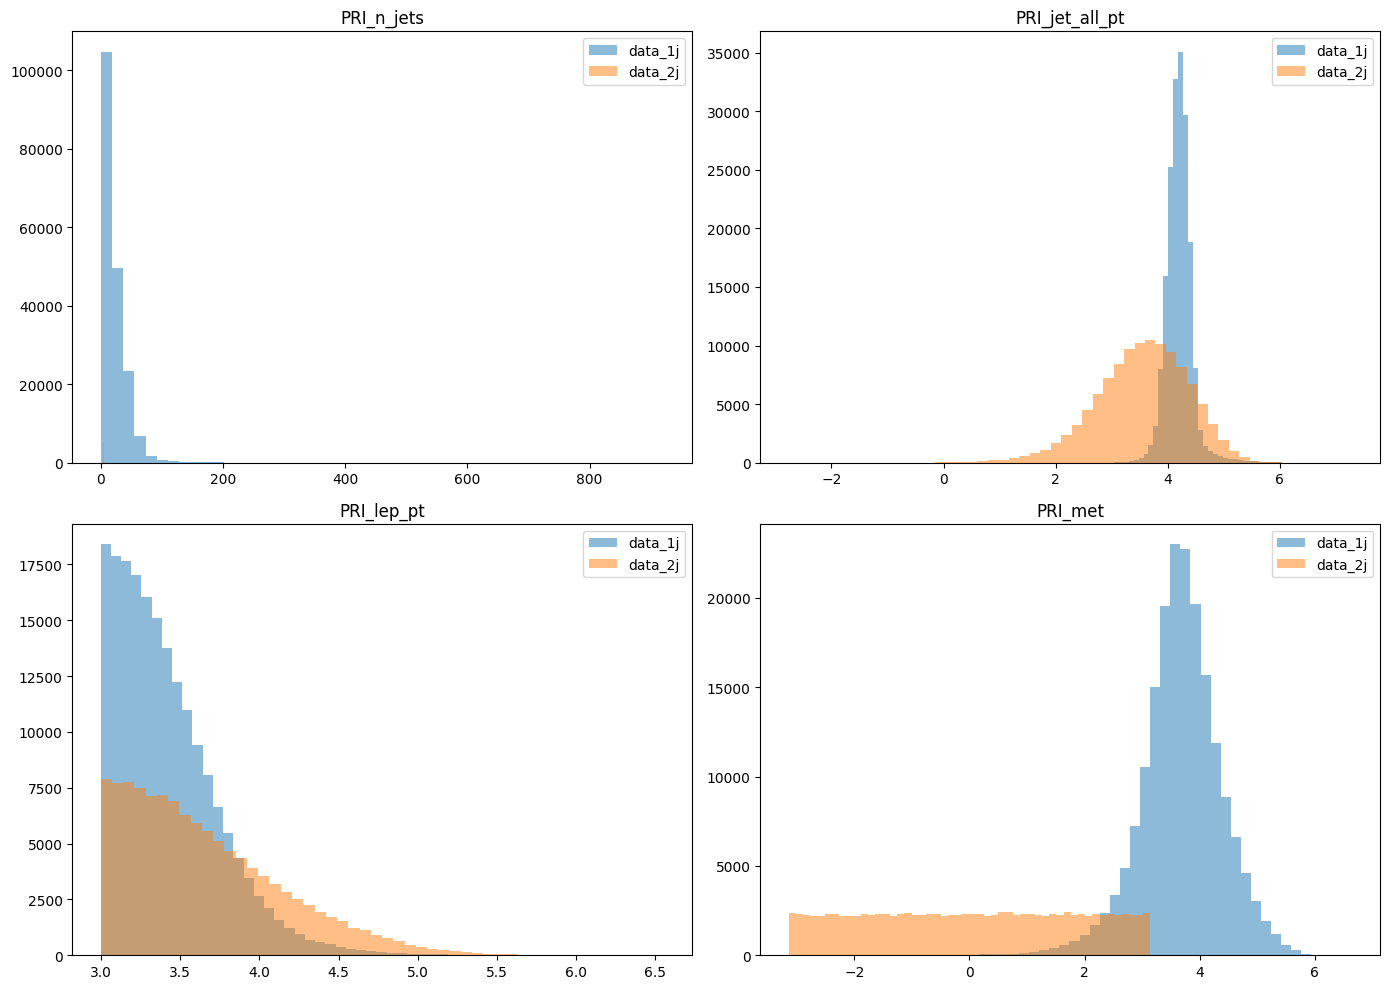

In [23]:
data_cols = [c for c in merged_df.columns if not str(c).lower().startswith("unnamed")]
col_names = ["PRI_n_jets", "PRI_jet_all_pt", "PRI_lep_pt", "PRI_met"]
col_idxs = [data_cols.index(name) for name in col_names]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, name, idx in zip(axes.ravel(), col_names, col_idxs):
    ax.hist(data_1j[:, idx], bins=50, alpha=0.5, label="data_1j")
    ax.hist(data_2j[:, idx], bins=50, alpha=0.5, label="data_2j")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()